<a href="https://colab.research.google.com/github/Manarsenic/EDA/blob/main/Global_Hunger%26Food_Security_Analysis_(2)_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing libraries and gathering urls

In [60]:
import pandas as pd
import requests
from io import StringIO

# 1. Dataset URLs from OWID
urls = {
    'undernourishment': "https://ourworldindata.org/grapher/prevalence-of-undernourishment.csv",
    'calorie_supply': "https://ourworldindata.org/grapher/daily-per-capita-caloric-supply.csv",
    'agri_employment': "https://ourworldindata.org/grapher/share-of-the-labor-force-employed-in-agriculture.csv",
    'stunting_rate': "https://ourworldindata.org/grapher/share-of-children-younger-than-5-who-suffer-from-stunting.csv",
    'severe_food_insecurity': "https://ourworldindata.org/grapher/global-hunger-index-vs-gdp-per-capita.csv?v=1&csvType=full&useColumnShortNames=true",
    'global_hunger_index': "https://ourworldindata.org/grapher/global-hunger-index.csv",
    'children_wasted': "https://ourworldindata.org/grapher/share-of-children-with-a-weight-too-low-for-their-height-wasting.csv",
    'food_loss_index': "https://ourworldindata.org/grapher/global-food-loss-index.csv",
    'price_of_healthy': "https://ourworldindata.org/grapher/cost-foods-healthy-diet.csv",
    'population': "https://ourworldindata.org/grapher/population.csv",
    'gdp_per_capita': "https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv"
}

Scraping and storing datasets

In [61]:
dataframes = {}
for name, url in urls.items():
    try:
        resp = requests.get(url)
        resp.raise_for_status()
        dataframes[name] = pd.read_csv(StringIO(resp.text))
        print(f"Successfully loaded '{name}'")
    except Exception as e:
        print(f"Error loading '{name}': {e}")

Successfully loaded 'undernourishment'
Successfully loaded 'calorie_supply'
Successfully loaded 'agri_employment'
Successfully loaded 'stunting_rate'
Successfully loaded 'severe_food_insecurity'
Successfully loaded 'global_hunger_index'
Successfully loaded 'children_wasted'
Successfully loaded 'food_loss_index'
Successfully loaded 'price_of_healthy'
Successfully loaded 'population'
Successfully loaded 'gdp_per_capita'


Renaming columns to make them easier to read

In [62]:
dataframes['undernourishment'] = dataframes['undernourishment'].rename(columns={'2.1.1 Prevalence of undernourishment | 000000000024000 || Value | 006121 || percent': 'undernourishment_rate'})
dataframes['stunting_rate'] = dataframes['stunting_rate'].rename(columns={'Stunting prevalence among children under 5 years of age (% height-for-age <-2 SD), model-based estimates - Sex: both sexes': 'stunting_rate'})
dataframes['severe_food_insecurity'] = dataframes['severe_food_insecurity'].rename(columns={'Global Hunger Index (2021)': 'severe_food_insecurity_rate', 'ny_gdp_pcap_pp_kd': 'gdp_per_capita'})
dataframes['global_hunger_index'] = dataframes['global_hunger_index'].rename(columns={'Global Hunger Index (2021)': 'global_hunger_index'})
dataframes['children_wasted'] = dataframes['children_wasted'].rename(columns={'Prevalence of wasting, weight for height (% of children under 5)': 'children_wasted_rate'})
dataframes['food_loss_index'] = dataframes['food_loss_index'].rename(columns={'12.3.1 - Global food loss index - AG_FLS_INDEX': 'food_loss_index'})
dataframes['price_of_healthy'] = dataframes['price_of_healthy'].rename(columns={
    'Cost of starchy staples': 'starchy_staples_cost',
    'Cost of legumes, nuts and seeds': 'legumes_nuts_seeds_cost',
    'Cost of oils and fats': 'oils_fats_cost',
    'Cost of fruits': 'fruits_cost',
    'Cost of vegetables': 'vegetables_cost',
    'Cost of animal-source foods': 'animal_source_foods_cost'
})
dataframes['population'] = dataframes['population'].rename(columns={'Population (historical)': 'population'})
dataframes['gdp_per_capita'] = dataframes['gdp_per_capita'].rename(columns={'GDP per capita, PPP (constant 2021 international $)': 'gdp_per_capita'})
dataframes['calorie_supply'] = dataframes['calorie_supply'].rename(columns={'Daily calorie supply per person': 'calorie_supply_per_person'})
dataframes['agri_employment'] = dataframes['agri_employment'].rename(columns={'share_employed_agri': 'agri_employment_share'})

Merging the dataframe

In [63]:
# Starting with the first dataframe and merge all others onto it
df = list(dataframes.values())[0]

for name, df_to_merge in list(dataframes.items())[1:]:
    # Ensure all dataframes have the same 'Entity', 'Code', and 'Year' columns
    common_cols = ['Entity', 'Code', 'Year']
    # If a dataframe lacks 'Code', merge only on 'Entity' and 'Year'
    if 'Code' not in df_to_merge.columns:
        common_cols.remove('Code')

    df = pd.merge(df, df_to_merge, on=common_cols, how='outer')
    print(f"Merged '{name}'. Current shape: {df.shape}")

Merged 'calorie_supply'. Current shape: (13453, 5)
Merged 'agri_employment'. Current shape: (15358, 6)
Merged 'stunting_rate'. Current shape: (16972, 7)
Merged 'severe_food_insecurity'. Current shape: (64121, 12)
Merged 'global_hunger_index'. Current shape: (64121, 14)
Merged 'children_wasted'. Current shape: (64121, 15)
Merged 'food_loss_index'. Current shape: (64148, 16)
Merged 'price_of_healthy'. Current shape: (64152, 22)
Merged 'population'. Current shape: (64152, 23)
Merged 'gdp_per_capita'. Current shape: (64152, 25)


Filtering recent data

In [64]:
#Filter for years 2000 and above
df_final = df[df['Year'] >= 2000]
#Final cleaning and renaming
df_final = df_final.rename(columns={'Entity': 'country', 'Year': 'year', 'Code': 'code'})
df_final.shape

(9359, 25)

In [65]:
# Identify columns with a high percentage of null values
null_counts = df_final.isnull().sum()
total_rows = len(df_final)
null_percentages = (null_counts / total_rows) * 100

# Define a threshold for considering a column "mostly null" (e.g., > 50% null)
null_threshold = 50

# Get the list of columns to drop based on the threshold
columns_to_drop_threshold = null_percentages[null_percentages > null_threshold].index.tolist()

# Add specific columns identified as having very few non-null values
# Note: 'global_hunger_index' has been removed from this list as per your request
specific_columns_to_drop = [ 'population_historical','severe_food_insecurity_rate','children_wasted_rate', 'food_loss_index',
                            'starchy_staples_cost','legumes_nuts_seeds_cost', 'oils_fats_cost', 'fruits_cost',
                            'vegetables_cost', 'animal_source_foods_cost', 'World regions according to OWID', 'gdp_per_capita_x',]

# Combine and remove duplicates
columns_to_drop = list(set(columns_to_drop_threshold + specific_columns_to_drop))

# Filter out columns that don't exist in the DataFrame
columns_to_drop_existing = [col for col in columns_to_drop if col in df_final.columns]

# Drop the identified columns
df_final = df_final.drop(columns=columns_to_drop_existing)

print("Columns dropped:")
print(columns_to_drop)
print("\nUpdated DataFrame shape:", df_final.shape)

Columns dropped:
['vegetables_cost', 'fruits_cost', 'legumes_nuts_seeds_cost', 'population_historical', 'global_hunger_index', 'food_loss_index', '411773-annotations_y', 'starchy_staples_cost', 'oils_fats_cost', 'animal_source_foods_cost', 'World regions according to OWID', 'gdp_per_capita_x', '411773-annotations_x', 'children_wasted_rate', 'owid_region', 'severe_food_insecurity_rate']

Updated DataFrame shape: (9359, 9)


In [66]:
print(df_final.columns.tolist())

['country', 'code', 'year', 'undernourishment_rate', 'calorie_supply_per_person', 'agri_employment_share', 'stunting_rate', 'population', 'gdp_per_capita_y']


In [67]:
df_final['year'] = df_final['year'].astype(int)

Preprocessing the Values

In [68]:
#Replacing Null values with median
columns_to_impute_median = [
    'undernourishment_rate',
    'calorie_supply_per_person',
    'agri_employment_share',
    'stunting_rate'
]

# Loop through each column and perform median imputation
for column in columns_to_impute_median:
    median_value = df_final[column].median()
    df_final[column] = df_final[column].fillna(median_value)
    print(f"Filled missing values in '{column}' with its median.")


Filled missing values in 'undernourishment_rate' with its median.
Filled missing values in 'calorie_supply_per_person' with its median.
Filled missing values in 'agri_employment_share' with its median.
Filled missing values in 'stunting_rate' with its median.


In [69]:
#Replacing null values with mean
# Impute 'population' with the mean
mean_population = df_final['population'].mean()
df_final['population'] = df_final['population'].fillna(mean_population)
print(f"Filled missing values in 'population' with its mean.")

Filled missing values in 'population' with its mean.


KNN Imputer for null values in gdp per capita

In [70]:
from sklearn.impute import KNNImputer

# Select only numerical columns needed for KNN Imputer
numeric_cols = df_final.select_dtypes(include=['float64', 'int64']).columns

# Initialize KNN Imputer
imputer = KNNImputer(n_neighbors=5)

# Fit and transform the numeric data
df_final[numeric_cols] = imputer.fit_transform(df_final[numeric_cols])

# Check if nulls in gdp_per_capita are filled
print(df_final['gdp_per_capita_y'].isnull().sum())


0


In [71]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9359 entries, 237 to 64151
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    9359 non-null   object 
 1   code                       6007 non-null   object 
 2   year                       9359 non-null   float64
 3   undernourishment_rate      9359 non-null   float64
 4   calorie_supply_per_person  9359 non-null   float64
 5   agri_employment_share      9359 non-null   float64
 6   stunting_rate              9359 non-null   float64
 7   population                 9359 non-null   float64
 8   gdp_per_capita_y           9359 non-null   float64
dtypes: float64(7), object(2)
memory usage: 731.2+ KB


SCRAPING GHI USING BEAUTIFUL SOUP

In [72]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import warnings

# Suppress BeautifulSoup's UserWarning for HTML parser
warnings.filterwarnings("ignore", category=UserWarning)

def get_ghi_data(url):
    """
    Scrapes the Global Hunger Index (GHI) data from Wikipedia and returns a DataFrame.
    """
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')

    # The GHI table is assumed to be the second table with "wikitable" class
    tables = soup.find_all("table", {"class": "wikitable"})

    if len(tables) < 2:
        print("GHI table not found on the webpage.")
        return None

    ghi_table = tables[1]
    rows = ghi_table.find_all("tr")

    # Extract header row and handle potential duplicates
    header_cols = [th.text.strip() for th in rows[0].find_all('th')]
    cleaned_header = []
    seen = {}
    for col in header_cols:
        if col in seen:
            seen[col] += 1
            cleaned_header.append(f"{col}_{seen[col]}")
        else:
            seen[col] = 1
            cleaned_header.append(col)

    data = []
    for row in rows[1:]:
        cols = row.find_all(["th", "td"])
        cols = [ele.text.strip() for ele in cols]
        data.append(cols)

    df_ghi_wiki = pd.DataFrame(data, columns=cleaned_header)
    return df_ghi_wiki

# URL for the 2024 GHI data on Wikipedia
url = "https://en.wikipedia.org/wiki/Global_Hunger_Index#2024_GHI:_Gender_Justice,_Climate_Resilience_and_Food_and_Nutrition_Security"

# Scrape the data
df_ghi_wiki = get_ghi_data(url)

if df_ghi_wiki is not None:
    print("2024 GHI data (df_ghi_wiki) has been successfully scraped.")
    print("Here's a preview of your new DataFrame:")
    print(df_ghi_wiki.head())

2024 GHI data (df_ghi_wiki) has been successfully scraped.
Here's a preview of your new DataFrame:
  Rank in 2023 Rank in 2015                 Country  2000 2008 2015 2023  \
0      1-20[a]         1-15                 Belarus    <5   <5   <5   <5   
1      1-20[a]           19  Bosnia and Herzegovina   9.4  6.5  5.3   <5   
2      1-20[a]         1-15                   Chile    <5   <5   <5   <5   
3      1-20[a]         1-15       China (more info)  13.4  7.1   <5   <5   
4      1-20[a]         1-15                 Croatia    <5   <5   <5   <5   

  Absolute changesince 2015 Percent changesince 2015  
0                         —                        —  
1                         —                        —  
2                         —                        —  
3                         —                        —  
4                         —                        —  


CLEANING IT FOR PLOTTING AND PREPROCESSING FOR THE 2ND DATAFRAME

In [73]:
# Create a new DataFrame without the specified columns
columns_to_drop = ['Rank in 2023', 'Rank in 2015', 'Absolute changesince 2015', 'Percent changesince 2015']
df_ghi_wiki_cleaned = df_ghi_wiki.drop(columns=columns_to_drop)

# Alternatively, you can drop the columns directly from the original DataFrame
# Note: This modifies the DataFrame in place and does not return a new object.
df_ghi_wiki.drop(columns=columns_to_drop, inplace=True)
df_ghi_wiki

,Country,2000,2008,2015,2023
0,Belarus,<5,<5,<5,<5
1,Bosnia and Herzegovina,9.4,6.5,5.3,<5
2,Chile,<5,<5,<5,<5
3,China (more info),13.4,7.1,<5,<5
4,Croatia,<5,<5,<5,<5
...,...,...,...,...,...
127,Somalia (famine),63.6,59.2,—,35–49.9[b]
128,Burundi,—,—,—,35–49.9[b]
129,South Sudan (famine),—,—,—,35–49.9[b]
130,None,None,None,None,None


**THE PLOTS**

In [74]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#for choropleth
import plotly.express as px

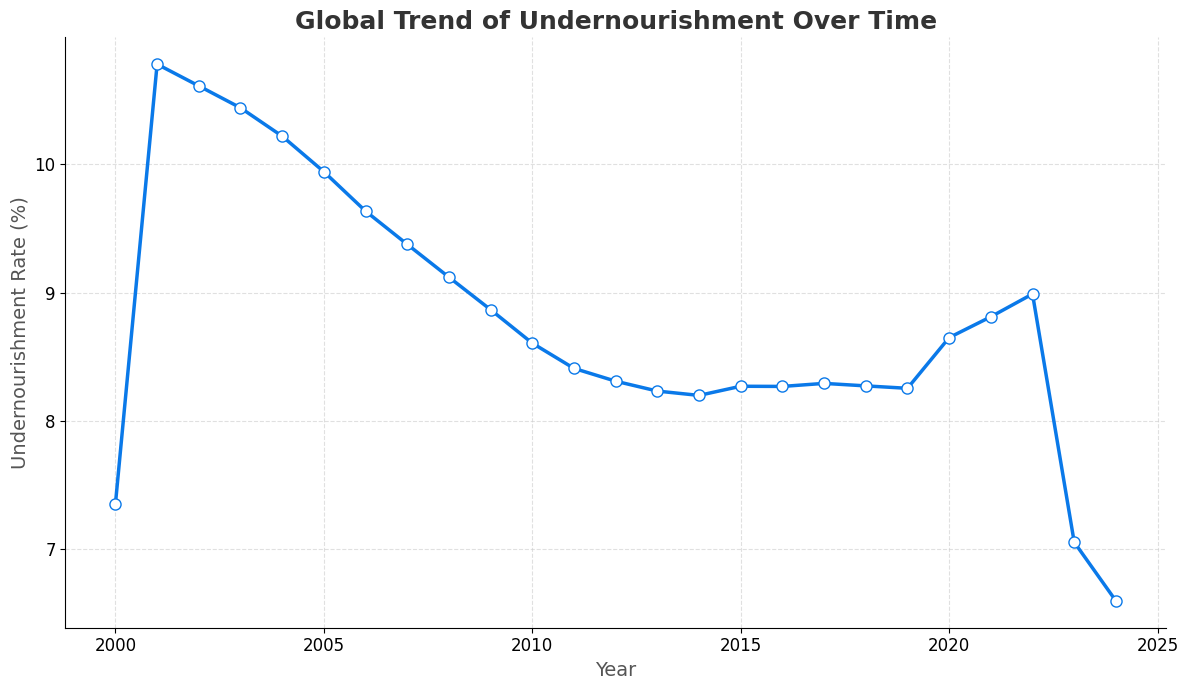

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean of key indicators per year
global_trend = df_final.groupby('year')['undernourishment_rate'].mean()

plt.figure(figsize=(12, 7))
plt.plot(global_trend.index, global_trend.values,
         marker='o', linestyle='-', color='#0A79E9', # A distinct color
         linewidth=2.5, markersize=8, markerfacecolor='white', markeredgecolor='#0A79E9')
plt.title("Global Trend of Undernourishment Over Time", fontsize=18, fontweight='bold', color='#333333')
plt.xlabel("Year", fontsize=14, color='#555555')
plt.ylabel("Undernourishment Rate (%)", fontsize=14, color='#555555')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6, color='#CCCCCC')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

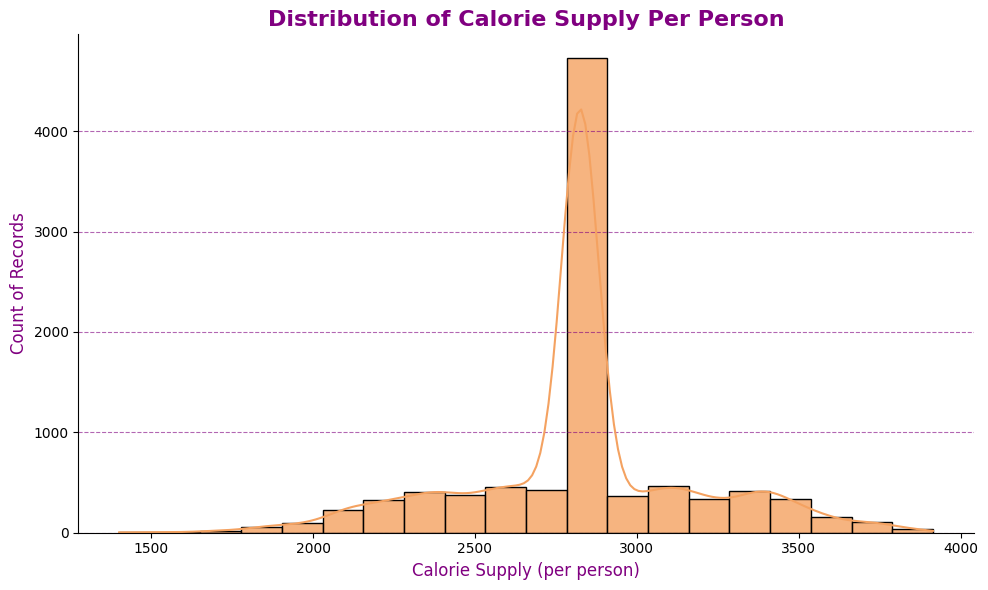

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_final['calorie_supply_per_person'], bins=20, kde=True,
             color='#F4A261', edgecolor='black', linewidth=1, alpha=0.8)
plt.title('Distribution of Calorie Supply Per Person', fontsize=16, fontweight='bold', color='purple')
plt.xlabel('Calorie Supply (per person)', fontsize=12, color='purple')
plt.ylabel('Count of Records', fontsize=12, color='purple')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6, color='purple')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1455237296.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




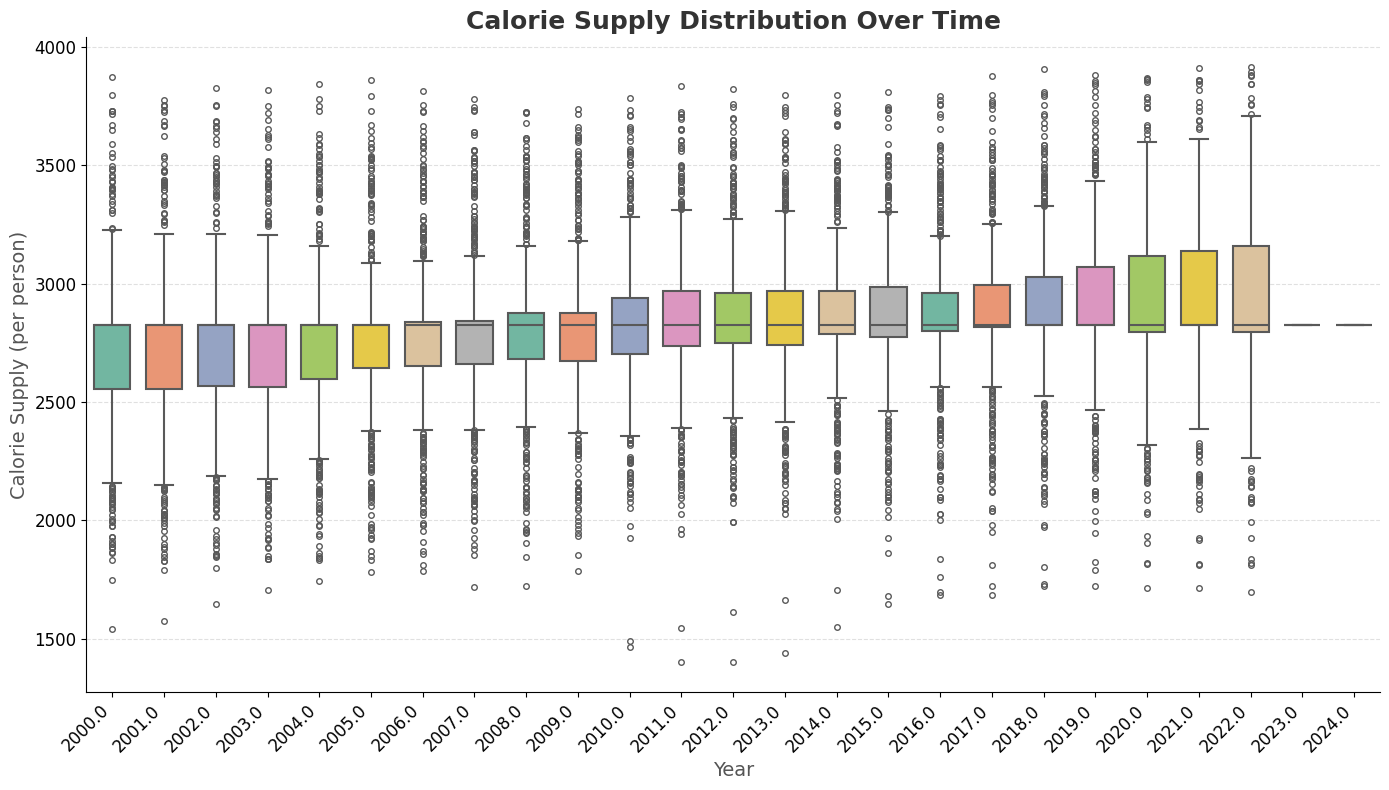

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.boxplot(x='year', y='calorie_supply_per_person', data=df_final,
            palette='Set2', width=0.7, linewidth=1.5, fliersize=4) # Fliers are outliers
plt.title('Calorie Supply Distribution Over Time', fontsize=18, fontweight='bold', color='#333333')
plt.xlabel('Year', fontsize=14, color='#555555')
plt.ylabel('Calorie Supply (per person)', fontsize=14, color='#555555')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6, color='#CCCCCC')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

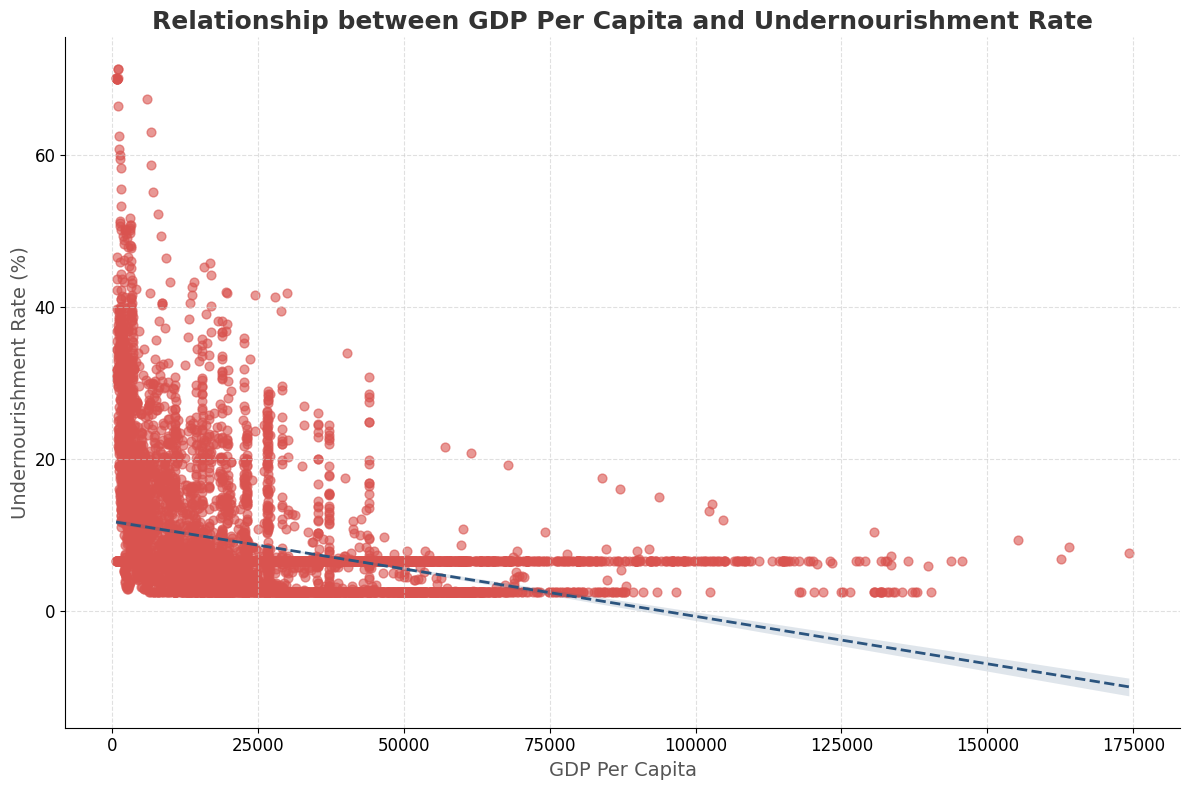

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.regplot(x='gdp_per_capita_y', y='undernourishment_rate', data=df_final,
            scatter_kws={'alpha':0.6, 's': 40, 'color': '#D9534F'}, # Customize scatter points
            line_kws={'color':'#2B547E', 'linestyle': '--', 'linewidth': 2}) # Add a regression line
plt.title('Relationship between GDP Per Capita and Undernourishment Rate', fontsize=18, fontweight='bold', color='#333333')
plt.xlabel('GDP Per Capita', fontsize=14, color='#555555')
plt.ylabel('Undernourishment Rate (%)', fontsize=14, color='#555555')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6, color='#CCCCCC')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

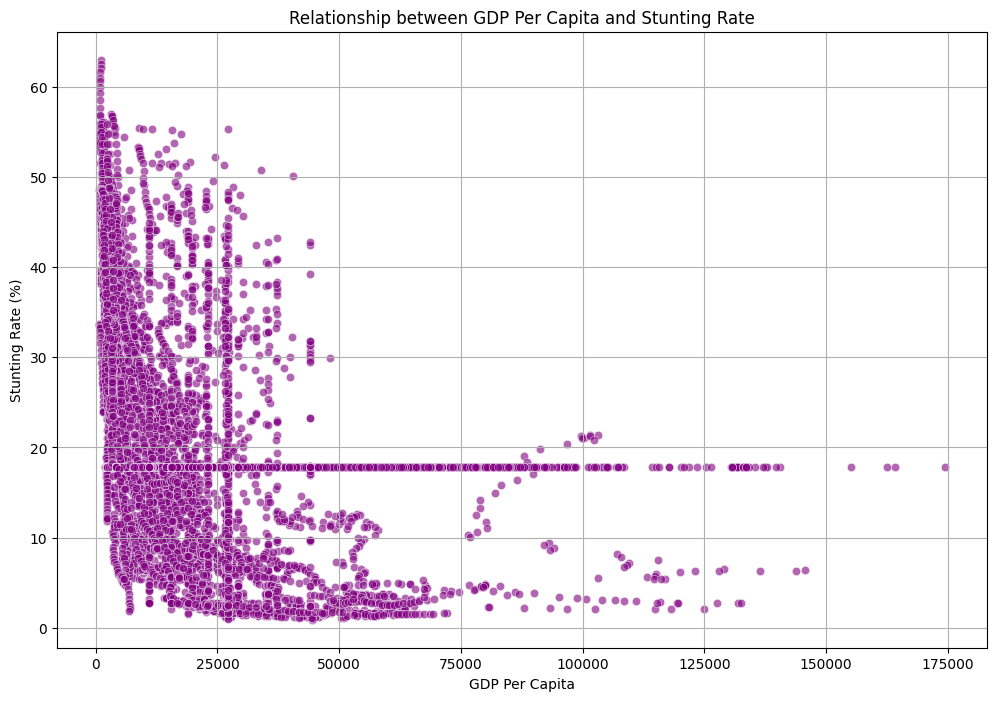

In [79]:
# Plot 5: Scatter plot for GDP vs. Stunting Rate
plt.figure(figsize=(12, 8))
sns.scatterplot(x='gdp_per_capita_y', y='stunting_rate', data=df_final, alpha=0.6, color='purple')
plt.title('Relationship between GDP Per Capita and Stunting Rate')
plt.xlabel('GDP Per Capita')
plt.ylabel('Stunting Rate (%)')
plt.grid(True)
plt.show()

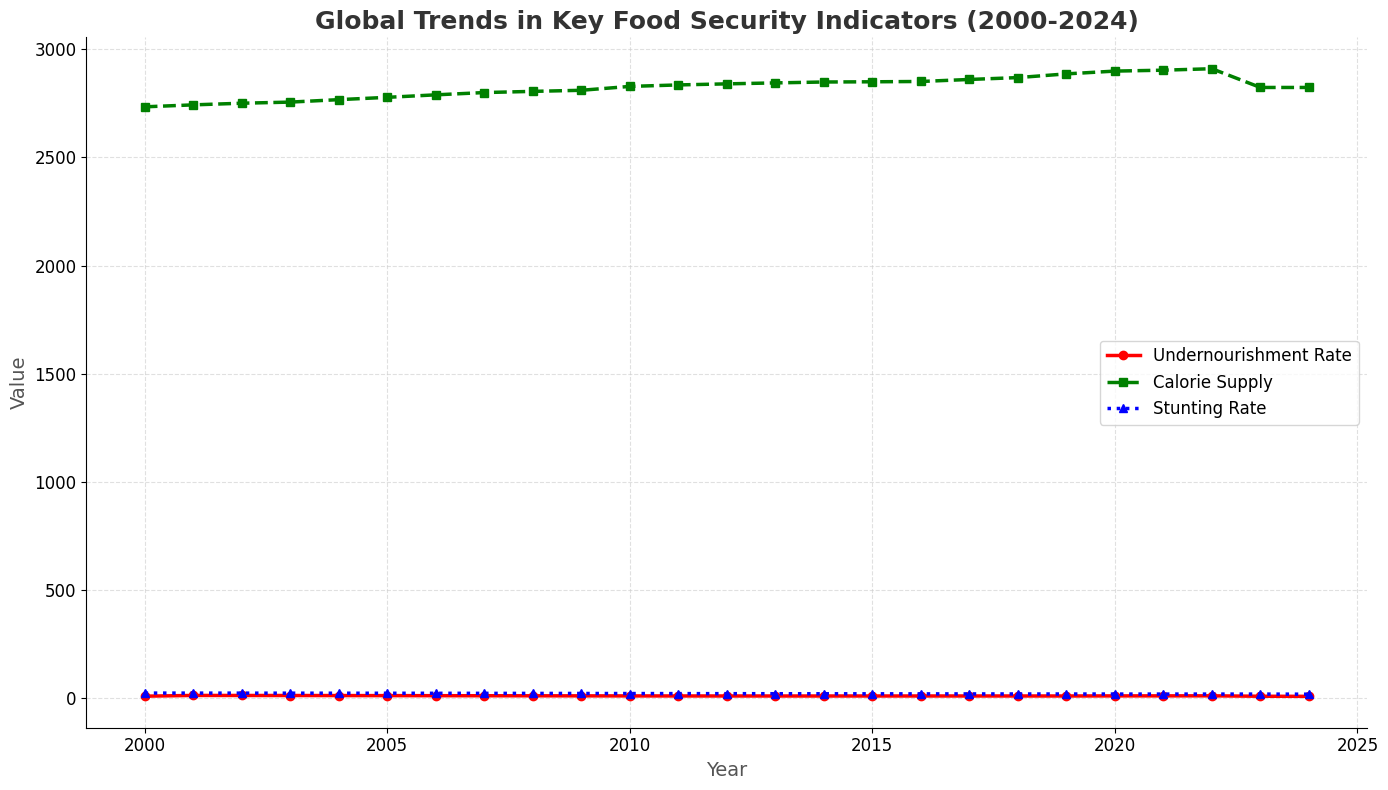

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

global_trends = df_final.groupby('year')[['undernourishment_rate', 'calorie_supply_per_person', 'stunting_rate']].mean()

plt.figure(figsize=(14, 8))
plt.plot(global_trends.index, global_trends['undernourishment_rate'],
         marker='o', linestyle='-', color='red', linewidth=2.5, label='Undernourishment Rate')
plt.plot(global_trends.index, global_trends['calorie_supply_per_person'],
         marker='s', linestyle='--', color='green', linewidth=2.5, label='Calorie Supply')
plt.plot(global_trends.index, global_trends['stunting_rate'],
         marker='^', linestyle=':', color='blue', linewidth=2.5, label='Stunting Rate')

plt.title('Global Trends in Key Food Security Indicators (2000-2024)', fontsize=18, fontweight='bold', color='#333333')
plt.xlabel('Year', fontsize=14, color='#555555')
plt.ylabel('Value', fontsize=14, color='#555555')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6, color='#CCCCCC')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

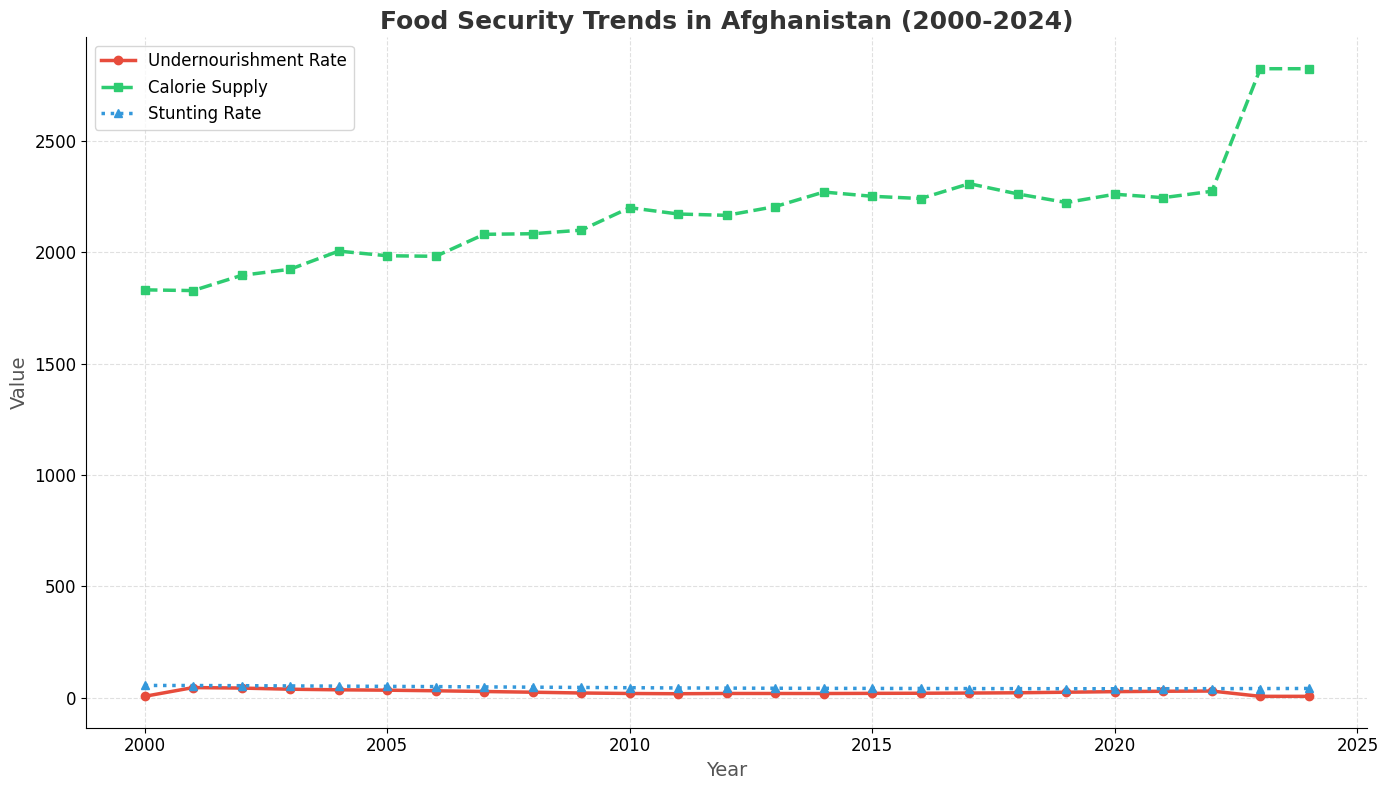

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

afghanistan_data = df_final[df_final['country'] == 'Afghanistan'].sort_values('year')

plt.figure(figsize=(14, 8), facecolor='white')
plt.plot(afghanistan_data['year'], afghanistan_data['undernourishment_rate'],
         marker='o', linestyle='-', color='#E74C3C', linewidth=2.5, label='Undernourishment Rate')
plt.plot(afghanistan_data['year'], afghanistan_data['calorie_supply_per_person'],
         marker='s', linestyle='--', color='#2ECC71', linewidth=2.5, label='Calorie Supply')
plt.plot(afghanistan_data['year'], afghanistan_data['stunting_rate'],
         marker='^', linestyle=':', color='#3498DB', linewidth=2.5, label='Stunting Rate')

plt.title('Food Security Trends in Afghanistan (2000-2024)', fontsize=18, fontweight='bold', color='#333333')
plt.xlabel('Year', fontsize=14, color='#555555')
plt.ylabel('Value', fontsize=14, color='#555555')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6, color='#CCCCCC')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [82]:
# Plot 8: Choropleth Map of Undernourishment Rate for the Latest Year
# Find the latest year for each country
df_latest_year = df_final.sort_values('year', ascending=False).drop_duplicates('country')

# Create the choropleth map
fig = px.choropleth(df_latest_year,
                    locations="code",
                    color="undernourishment_rate",
                    hover_name="country",
                    animation_frame="year",
                    color_continuous_scale=px.colors.sequential.YlOrRd,
                    title='Global Undernourishment Rate (Most Recent Year)')

fig.show()

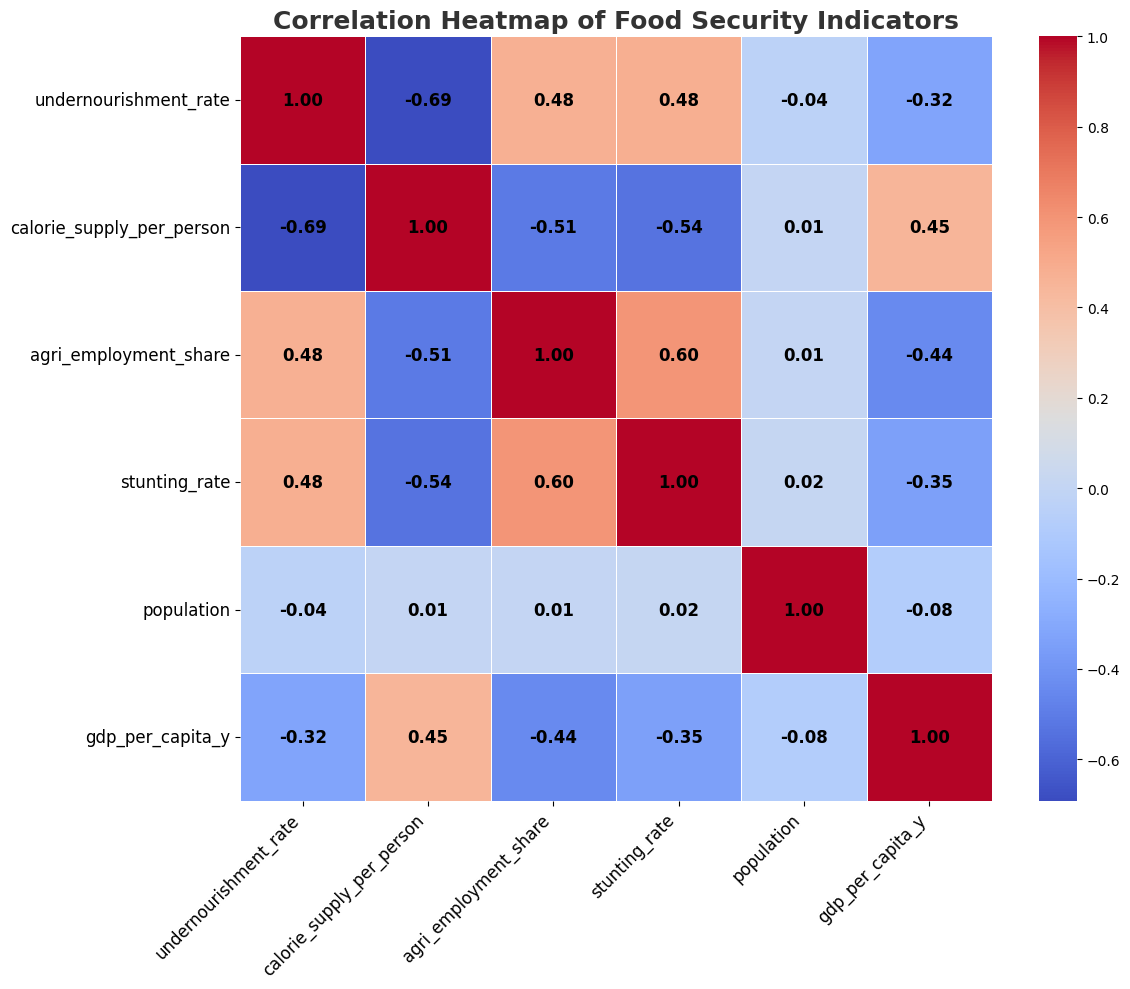

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the numerical columns for the correlation matrix
numerical_cols = [
    'undernourishment_rate',
    'calorie_supply_per_person',
    'agri_employment_share',
    'stunting_rate',
    'population',
    'gdp_per_capita_y'
]
df_numeric = df_final[numerical_cols]

# Calculate the correlation matrix
corr_matrix = df_numeric.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=.5, annot_kws={"size": 12, "weight": "bold", "color": "black"})
plt.title('Correlation Heatmap of Food Security Indicators', fontsize=18, fontweight='bold', color='#333333')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

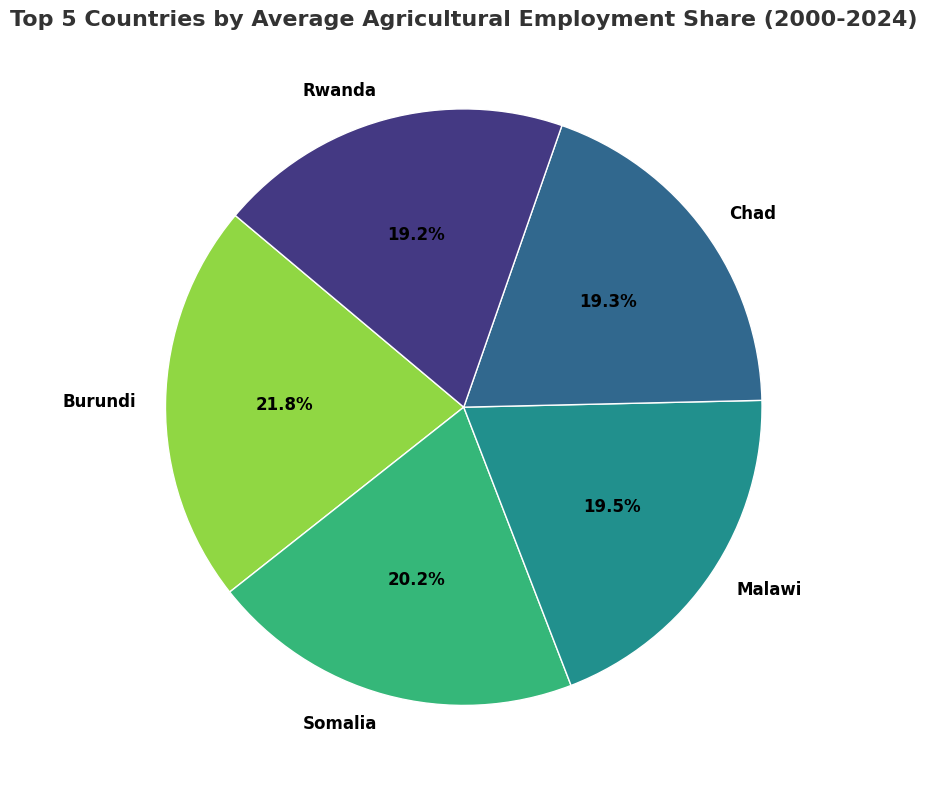

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

top_agri_employment = df_final.groupby('country')['agri_employment_share'].mean().nlargest(5)

plt.figure(figsize=(10, 8))
plt.pie(top_agri_employment, labels=top_agri_employment.index,
        autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette("viridis_r", len(top_agri_employment)),
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}, textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Top 5 Countries by Average Agricultural Employment Share (2000-2024)', fontsize=16, fontweight='bold', color='#333333')
plt.ylabel('')
plt.tight_layout()
plt.show()

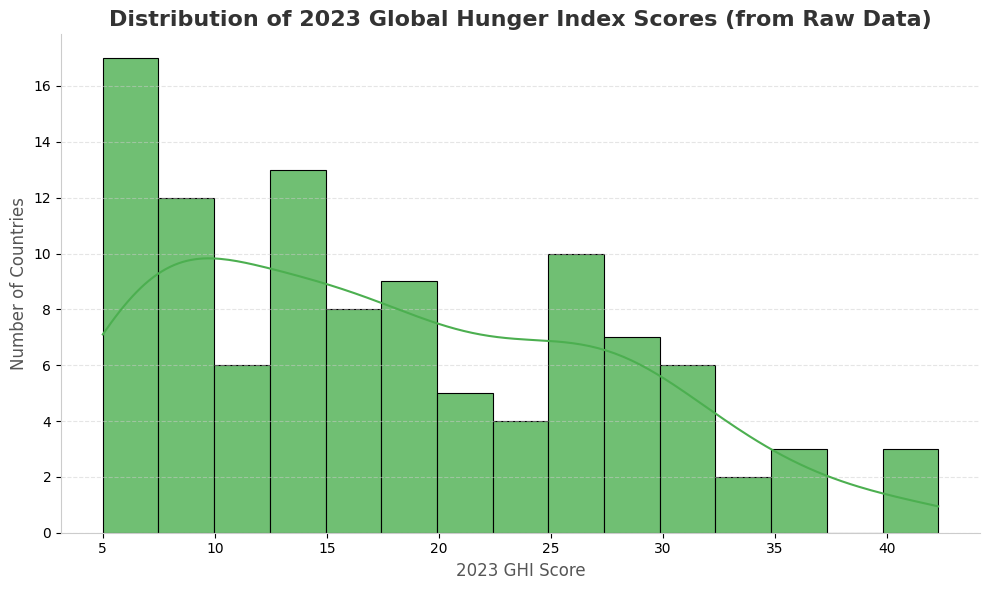

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- Use df_ghi_wiki directly ---
df_plot_data = df_ghi_wiki.copy()

# Rename the '2023' column for clarity in the plot
df_plot_data.rename(columns={'2023': 'global_hunger_index_2023'}, inplace=True)

# Convert 'global_hunger_index_2023' to numeric, coercing errors to NaN
df_plot_data['global_hunger_index_2023'] = pd.to_numeric(df_plot_data['global_hunger_index_2023'], errors='coerce')

# Drop rows with NaN GHI scores for plotting
df_plot_data.dropna(subset=['global_hunger_index_2023'], inplace=True)

if not df_plot_data.empty:
    plt.figure(figsize=(10, 6))

    sns.histplot(
        df_plot_data['global_hunger_index_2023'],
        bins=15,
        kde=True,
        color='#4CAF50', # A pleasant green color
        edgecolor='black', # Add black edges to bars
        linewidth=0.8,
        alpha=0.8
    )

    plt.title('Distribution of 2023 Global Hunger Index Scores (from Raw Data)', fontsize=16, fontweight='bold', color='#333333')
    plt.xlabel('2023 GHI Score', fontsize=12, color='#555555')
    plt.ylabel('Number of Countries', fontsize=12, color='#555555')
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc') # Lighter grid

    # Add a border around the plot area
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_edgecolor('#cccccc')
    plt.gca().spines['bottom'].set_edgecolor('#cccccc')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ `df_ghi_wiki` has no valid numeric GHI scores after minimal cleaning for plotting. Cannot plot histogram.")



/tmp/ipython-input-3112584199.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




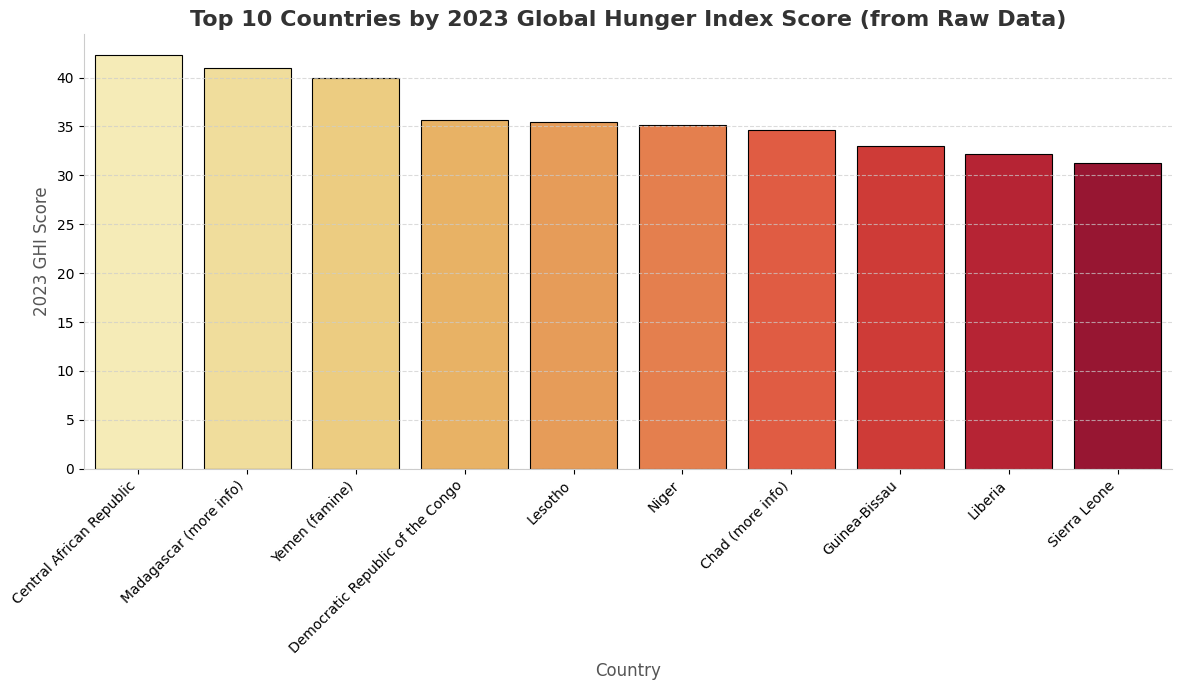

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
# --- Use df_ghi_wiki directly ---
df_plot_data = df_ghi_wiki.copy()
# Rename columns for clarity and consistency
df_plot_data.rename(columns={
    'Country': 'country',
    '2023': 'global_hunger_index_2023'
}, inplace=True)
# Convert GHI score to numeric, coercing errors to NaN
df_plot_data['global_hunger_index_2023'] = pd.to_numeric(df_plot_data['global_hunger_index_2023'], errors='coerce')
# Extract country name by removing (ISO) part
df_plot_data['country'] = df_plot_data['country'].apply(
    lambda x: re.sub(r'\s*\([A-Z]{3}\)', '', str(x)).strip()
)
# Drop rows with NaN GHI scores for plotting
df_plot_data.dropna(subset=['global_hunger_index_2023'], inplace=True)
if not df_plot_data.empty:
    # Sort and select the top 10 countries by GHI score
    df_top_10_ghi = df_plot_data.sort_values(by='global_hunger_index_2023', ascending=False).head(10)

    plt.figure(figsize=(12, 7))
    sns.barplot(
        x='country',
        y='global_hunger_index_2023',
        data=df_top_10_ghi,
        palette='YlOrRd', # A nice sequential palette
        edgecolor='black', # Add black edges to bars
        linewidth=0.8
    )
    plt.title('Top 10 Countries by 2023 Global Hunger Index Score (from Raw Data)', fontsize=16, fontweight='bold', color='#333333')
    plt.xlabel('Country', fontsize=12, color='#555555')
    plt.ylabel('2023 GHI Score', fontsize=12, color='#555555')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='#cccccc') # Lighter grid
    # Add a border around the plot area
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_edgecolor('#cccccc')
    plt.gca().spines['bottom'].set_edgecolor('#cccccc')

    plt.tight_layout()
    plt.show()
else:
    print("  no valid.")

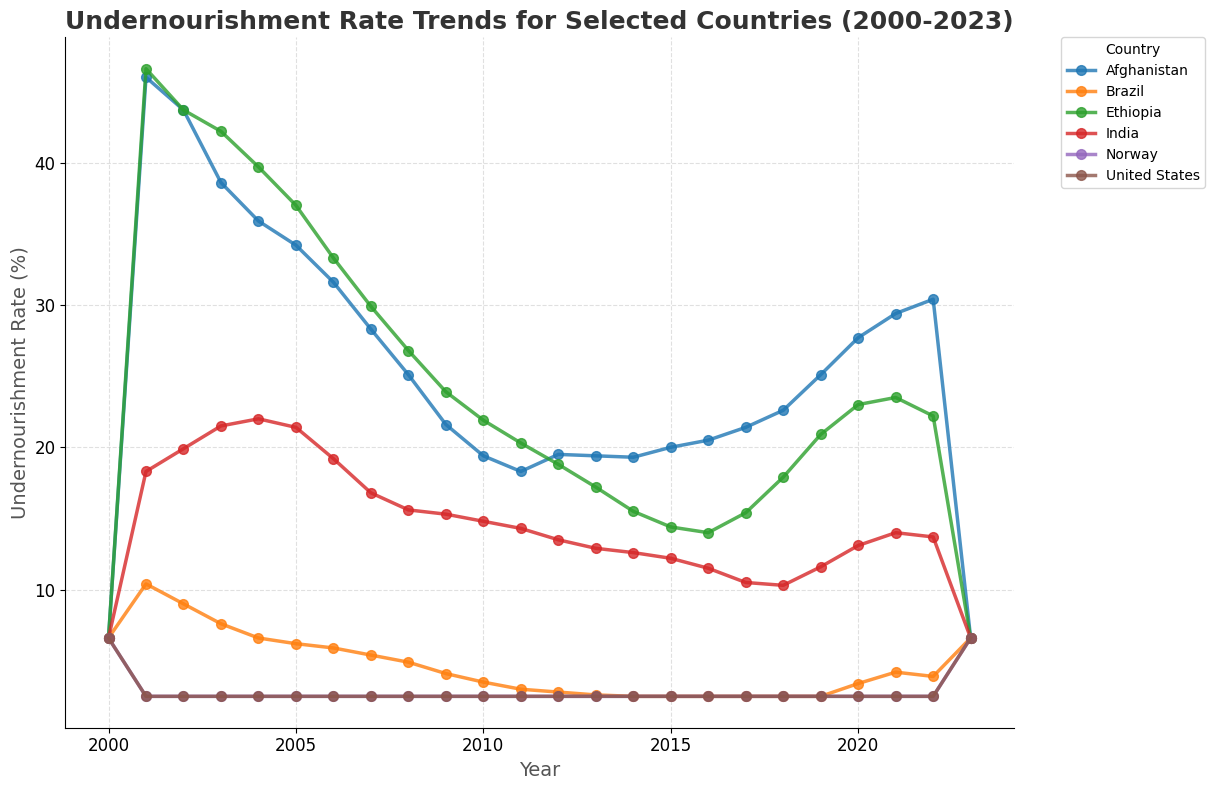

In [87]:

# Merging the dataframes
df = list(dataframes.values())[0]
for name, df_to_merge in list(dataframes.items())[1:]:
    common_cols = ['Entity', 'Code', 'Year']
    if 'Code' not in df_to_merge.columns:
        common_cols.remove('Code')
    df = pd.merge(df, df_to_merge, on=common_cols, how='outer')

# Filtering recent data
df_final = df[df['Year'] >= 2000].copy() # Ensure we're working on a copy
df_final.rename(columns={'Entity': 'country', 'Year': 'year', 'Code': 'code'}, inplace=True)
df_final['year'] = df_final['year'].astype(int)
# Drop columns with high null percentages and specific less relevant columns
null_counts = df_final.isnull().sum()
total_rows = len(df_final)
null_percentages = (null_counts / total_rows) * 100
null_threshold = 50
columns_to_drop_threshold = null_percentages[null_percentages > null_threshold].index.tolist()
specific_columns_to_drop = [
    'population_historical', 'severe_food_insecurity_rate', 'children_wasted_rate', 'food_loss_index',
    'starchy_staples_cost', 'legumes_nuts_seeds_cost', 'oils_fats_cost', 'fruits_cost',
    'vegetables_cost', 'animal_source_foods_cost', 'World regions according to OWID', 'gdp_per_capita_x'
]
columns_to_drop = list(set(columns_to_drop_threshold + specific_columns_to_drop))
columns_to_drop_existing = [col for col in columns_to_drop if col in df_final.columns]
df_final.drop(columns=columns_to_drop_existing, inplace=True)
# Preprocessing the Values (Imputation)
columns_to_impute_median = [
    'undernourishment_rate', 'calorie_supply_per_person', 'agri_employment_share', 'stunting_rate'
]
for column in columns_to_impute_median:
    median_value = df_final[column].median()
    df_final[column] = df_final[column].fillna(median_value)

mean_population = df_final['population'].mean()
df_final['population'] = df_final['population'].fillna(mean_population)

# KNN Imputer for gdp_per_capita_y
if 'gdp_per_capita_y' in df_final.columns:
    numeric_cols = df_final.select_dtypes(include=['float64', 'int64']).columns
    imputer = KNNImputer(n_neighbors=5)
    df_final[numeric_cols] = imputer.fit_transform(df_final[numeric_cols])
else:
    print("Warning: 'gdp_per_capita_y' not found in df_final. Skipping KNN imputation for it.")


# --- 2. Plotting the Undernourishment Rate Trends ---
# Select a few diverse countries for comparison
# You can customize this list to highlight specific countries of interest.
selected_countries_for_undernourishment = [
    'Afghanistan',
    'Ethiopia',
    'India',
    'Brazil',
    'United States',
    'Norway'
]
df_undernourishment_trends = df_final[
    df_final['country'].isin(selected_countries_for_undernourishment)
].pivot_table(
    index='year',
    columns='country',
    values='undernourishment_rate',
    aggfunc='mean' # Use mean in case of multiple entries per year/country
).dropna() # Drop years where any selected country has missing data
if not df_undernourishment_trends.empty:
    plt.figure(figsize=(14, 8))

    # Plot each country's trend
    for country in df_undernourishment_trends.columns:
        plt.plot(df_undernourishment_trends.index, df_undernourishment_trends[country],
                 marker='o', linestyle='-', linewidth=2.5, markersize=7, alpha=0.8,
                 label=country)

    plt.title('Undernourishment Rate Trends for Selected Countries (2000-2023)',
              fontsize=18, fontweight='bold', color='#333333')
    plt.xlabel('Year', fontsize=14, color='#555555')
    plt.ylabel('Undernourishment Rate (%)', fontsize=14, color='#555555')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6, color='#CCCCCC')
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjust layout to make space for legend
    plt.show()
else:
    print("⚠️ No data available for the selected countries or undernourishment rates after cleaning. Cannot plot.")

